# CMPE 255 Assignment 1 — Part 2
## Experiment 12: Time Series Forecasting

### AI-Assisted Replication of Instructor Data Science Experiment

This notebook replicates and adapts the time series forecasting experiment from the instructor's `data_science_examples` repository.

Time series forecasting focuses on predicting future values using observations collected sequentially over time.

Common applications include:

- Sales forecasting
- Demand planning
- Website traffic forecasting
- Energy consumption prediction
- Financial analysis
- Inventory management

### Objectives

- Create and explore a reproducible daily sales time series
- Identify trend and seasonal behavior
- Use a chronological train/test split
- Establish a naive forecasting baseline
- Engineer time-based and lag features
- Train forecasting models
- Evaluate forecasts using MAE and RMSE
- Visualize predicted versus actual values
- Generate a short future forecast

### Adaptation

For this assignment, a synthetic daily sales dataset is used so that trend and weekly seasonal patterns can be examined in a controlled and reproducible environment.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Business Understanding

Accurate sales forecasts can help businesses make decisions about inventory, staffing, purchasing, and promotions.

The objective of this experiment is to forecast future daily sales using historical sales patterns.

Unlike ordinary machine learning datasets, time series observations have a natural chronological order.

Future observations should not be randomly mixed into the training data because this could allow information from the future to influence model development.

Therefore, this experiment uses a chronological train/test split.

In [4]:
# Create reproducible daily sales data

np.random.seed(42)

dates = pd.date_range(
    start="2024-01-01",
    periods=730,
    freq="D"
)

time_index = np.arange(
    len(dates)
)

# Gradual upward trend
trend = 0.08 * time_index

# Weekly seasonality
weekly_pattern = (
    18 * np.sin(
        2 * np.pi * time_index / 7
    )
)

# Longer seasonal pattern
yearly_pattern = (
    12 * np.sin(
        2 * np.pi * time_index / 365
    )
)

# Random variation
noise = np.random.normal(
    0,
    8,
    len(dates)
)

sales = (
    150
    + trend
    + weekly_pattern
    + yearly_pattern
    + noise
)

sales_data = pd.DataFrame({
    "date": dates,
    "sales": sales
})

sales_data["sales"] = (
    sales_data["sales"]
    .clip(lower=0)
    .round(2)
)

print(
    "Dataset shape:",
    sales_data.shape
)

print(
    "Date range:",
    sales_data["date"].min(),
    "to",
    sales_data["date"].max()
)

sales_data.head()

Dataset shape: (730, 2)
Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00


,date,sales
0,2024-01-01,153.97
1,2024-01-02,163.25
2,2024-01-03,173.30
3,2024-01-04,170.85
4,2024-01-05,141.46


## 2. Data Understanding

The dataset contains 730 consecutive days of simulated sales observations.

The synthetic series includes:

- A gradual upward trend
- A repeating weekly pattern
- A longer seasonal pattern
- Random day-to-day variation

These components create a controlled forecasting problem while preserving important characteristics commonly observed in real business time series.

In [5]:
print("Missing values:")
print(sales_data.isnull().sum())

print("\nSales statistics:")
print(sales_data["sales"].describe())

Missing values:
date     0
sales    0
dtype: int64

Sales statistics:
count    730.000000
mean     179.066986
std       21.297455
min      124.320000
25%      162.605000
50%      179.125000
75%      194.965000
max      241.590000
Name: sales, dtype: float64


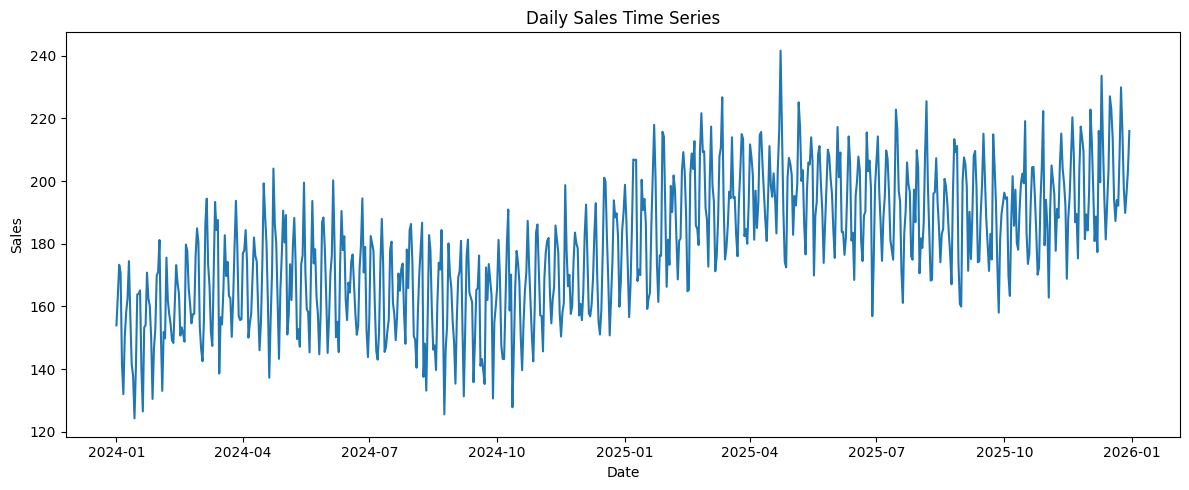

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    sales_data["date"],
    sales_data["sales"]
)

plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

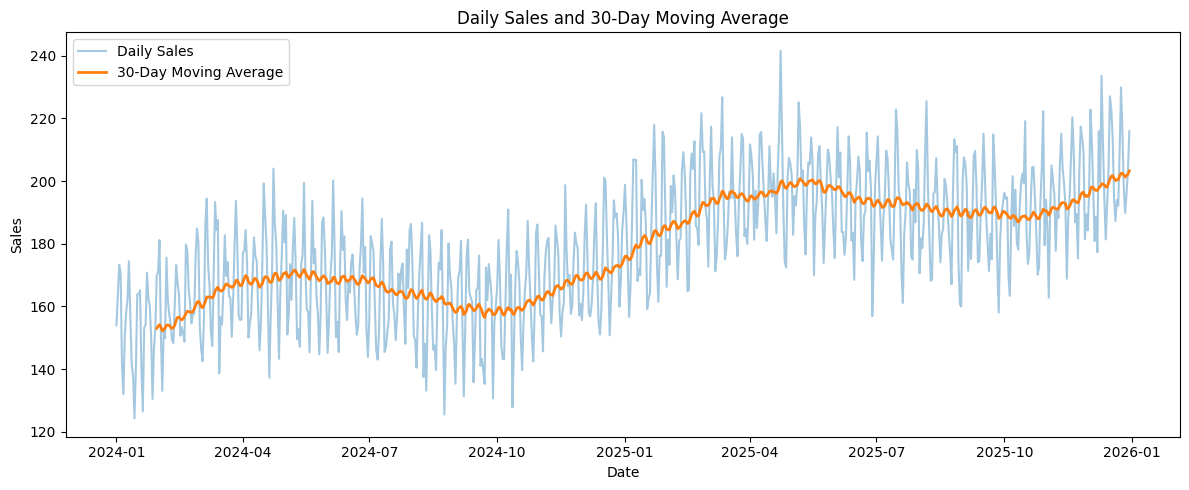

In [7]:
sales_data["30_day_average"] = (
    sales_data["sales"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    sales_data["date"],
    sales_data["sales"],
    alpha=0.4,
    label="Daily Sales"
)

plt.plot(
    sales_data["date"],
    sales_data["30_day_average"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("Daily Sales and 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.tight_layout()

plt.show()

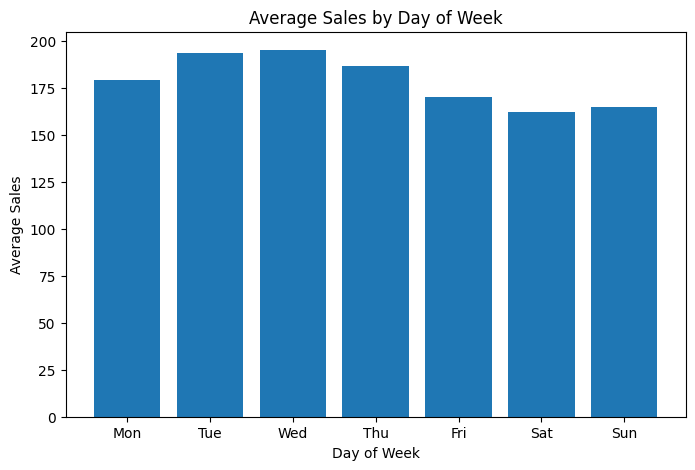

In [8]:
sales_data["day_of_week"] = (
    sales_data["date"].dt.dayofweek
)

weekday_sales = (
    sales_data
    .groupby("day_of_week")["sales"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    weekday_sales.index,
    weekday_sales.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(
    range(7),
    [
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "Sat",
        "Sun"
    ]
)

plt.show()

## 3. Feature Engineering

Several features are created from the historical time series.

### Time Features

- Time index
- Day of week
- Month

### Lag Features

Lag variables represent previous sales observations.

For example:

- `lag_1` = sales from one day earlier
- `lag_7` = sales from seven days earlier
- `lag_14` = sales from fourteen days earlier

Lag features allow the forecasting model to learn from recent and weekly historical behavior.

Only past observations are used to construct these predictors.

In [9]:
sales_data["time_index"] = np.arange(
    len(sales_data)
)

sales_data["month"] = (
    sales_data["date"].dt.month
)

sales_data["lag_1"] = (
    sales_data["sales"].shift(1)
)

sales_data["lag_7"] = (
    sales_data["sales"].shift(7)
)

sales_data["lag_14"] = (
    sales_data["sales"].shift(14)
)

model_data = (
    sales_data
    .dropna()
    .reset_index(drop=True)
)

print(
    "Modeling dataset shape:",
    model_data.shape
)

model_data.head()

Modeling dataset shape: (701, 9)


,date,sales,30_day_average,day_of_week,time_index,month,lag_1,lag_7,lag_14
0,2024-01-30,169.80,153.054333,1,29,1,153.00,170.81,163.84
1,2024-01-31,171.06,153.624000,2,30,1,169.80,162.62,163.99
2,2024-02-01,181.21,154.222667,3,31,2,171.06,160.19,165.15
3,2024-02-02,150.92,153.476667,4,32,2,181.21,150.08,140.02
4,2024-02-03,133.09,152.218000,5,33,2,150.92,130.52,126.53


## 4. Chronological Train/Test Split

A random train/test split is not used for this experiment.

Instead, the first 80% of observations are used for training and the most recent 20% are reserved for testing.

This simulates a realistic forecasting scenario:

> Train on the past and evaluate on the future.

The test period is never used to train the forecasting models.

In [10]:
split_index = int(
    len(model_data) * 0.80
)

train_data = model_data.iloc[
    :split_index
].copy()

test_data = model_data.iloc[
    split_index:
].copy()

print(
    "Training observations:",
    len(train_data)
)

print(
    "Testing observations:",
    len(test_data)
)

print(
    "\nTraining period:",
    train_data["date"].min(),
    "to",
    train_data["date"].max()
)

print(
    "\nTesting period:",
    test_data["date"].min(),
    "to",
    test_data["date"].max()
)

Training observations: 560
Testing observations: 141

Training period: 2024-01-30 00:00:00 to 2025-08-11 00:00:00

Testing period: 2025-08-12 00:00:00 to 2025-12-30 00:00:00


In [11]:
baseline_predictions = (
    test_data["lag_1"]
)

baseline_mae = mean_absolute_error(
    test_data["sales"],
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_data["sales"],
        baseline_predictions
    )
)

print("Naive Baseline Results")
print("----------------------")

print(
    "MAE:",
    round(baseline_mae, 2)
)

print(
    "RMSE:",
    round(baseline_rmse, 2)
)

Naive Baseline Results
----------------------
MAE: 13.07
RMSE: 15.86


In [12]:
features = [
    "time_index",
    "day_of_week",
    "month",
    "lag_1",
    "lag_7",
    "lag_14"
]

X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]


linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

print("Linear Regression Results")
print("-------------------------")

print(
    "MAE:",
    round(linear_mae, 2)
)

print(
    "RMSE:",
    round(linear_rmse, 2)
)

Linear Regression Results
-------------------------
MAE: 7.67
RMSE: 9.66


In [13]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest Results")
print("---------------------")

print(
    "MAE:",
    round(rf_mae, 2)
)

print(
    "RMSE:",
    round(rf_rmse, 2)
)

Random Forest Results
---------------------
MAE: 8.34
RMSE: 10.32


In [14]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ]
})

forecast_results.round(2)

,Model,MAE,RMSE
0,Naive Baseline,13.07,15.86
1,Linear Regression,7.67,9.66
2,Random Forest,8.34,10.32


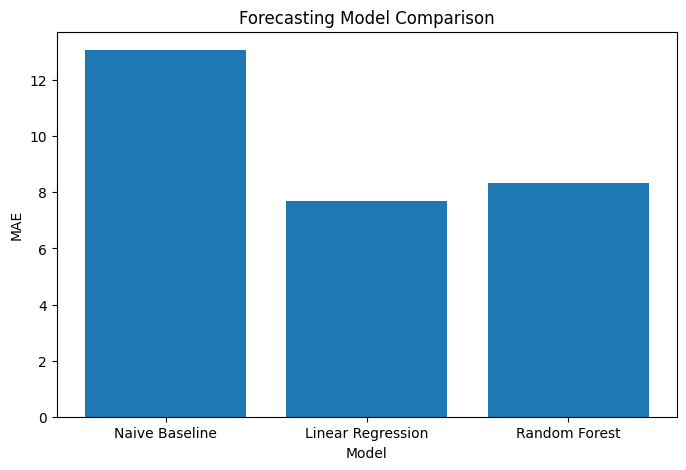

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    forecast_results["Model"],
    forecast_results["MAE"]
)

plt.title("Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.show()

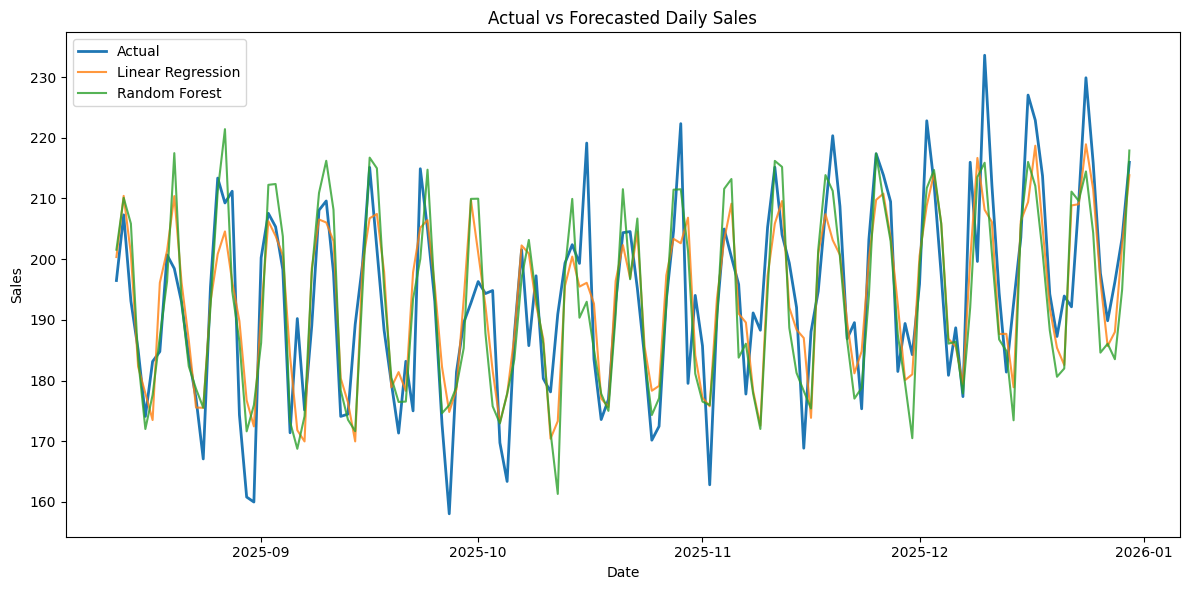

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_data["date"],
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_data["date"],
    linear_predictions,
    label="Linear Regression",
    alpha=0.8
)

plt.plot(
    test_data["date"],
    rf_predictions,
    label="Random Forest",
    alpha=0.8
)

plt.title("Actual vs Forecasted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.tight_layout()

plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance

,Feature,Importance
4,lag_7,0.448004
5,lag_14,0.419920
3,lag_1,0.047228
0,time_index,0.044156
1,day_of_week,0.025645
2,month,0.015046


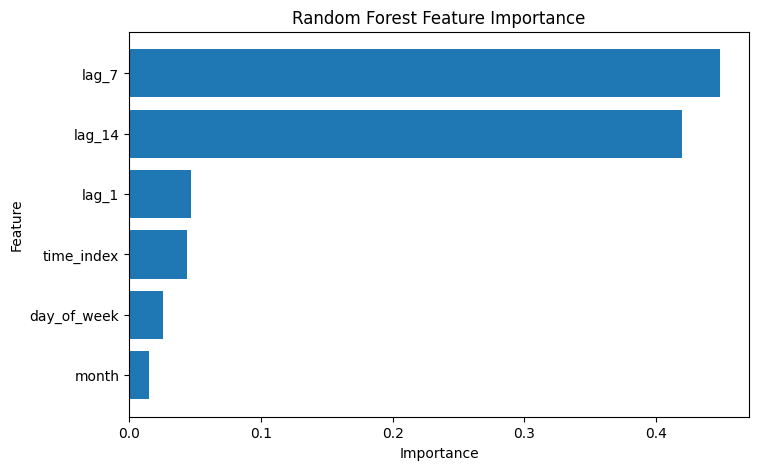

In [18]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 5. Forecast Evaluation

The forecasting approaches produced the following results:

- **Naive Baseline:** MAE = 13.07, RMSE = 15.86
- **Linear Regression:** MAE = 7.67, RMSE = 9.66
- **Random Forest:** MAE = 8.34, RMSE = 10.32

Linear Regression achieved the best overall forecasting performance.

Compared with the naive baseline, Linear Regression reduced MAE from 13.07 to 7.67, an improvement of approximately 41%.

Random Forest also substantially outperformed the baseline but performed slightly worse than Linear Regression.

This result demonstrates that a more complex model does not automatically produce a better forecast. The synthetic series contains relatively regular trend and seasonal patterns that can be represented effectively by the engineered time and lag features.

The forecast visualization also shows that both machine learning models capture the repeating weekly pattern, although individual daily fluctuations remain difficult to predict.

### Feature Interpretation

Random Forest feature importance provides additional insight into the historical patterns in the series.

The two most important features were:

- `lag_7` — importance approximately 0.448
- `lag_14` — importance approximately 0.420

Together, these two features account for most of the Random Forest feature importance.

This result is consistent with the weekly seasonal pattern built into the synthetic sales series. Sales from one and two weeks earlier provide strong information about sales on the current day.

The importance analysis therefore supports the exploratory observation that the time series contains a strong repeating weekly pattern.

Feature importance describes predictive usefulness within the model and should not be interpreted as evidence of causation.

## 6. 30-Day Future Forecast

Linear Regression achieved the lowest test MAE and RMSE, so it is selected for the final forecasting demonstration.

Because the model uses lag features, future observations must be generated sequentially.

A recursive forecasting approach is used:

1. Predict the next day using the available historical observations.
2. Add the prediction to the temporary sales history.
3. Use the updated history to construct lag features for the following day.
4. Repeat the process for 30 future days.

This approach avoids using unavailable future sales values when generating forecasts.

In [19]:
# Generate a 30-day recursive forecast using Linear Regression

future_days = 30

sales_history = sales_data["sales"].tolist()

last_date = sales_data["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_days,
    freq="D"
)

future_predictions = []

for future_date in future_dates:

    future_time_index = len(sales_history)

    future_day_of_week = future_date.dayofweek
    future_month = future_date.month

    lag_1 = sales_history[-1]
    lag_7 = sales_history[-7]
    lag_14 = sales_history[-14]

    future_features = pd.DataFrame({
        "time_index": [future_time_index],
        "day_of_week": [future_day_of_week],
        "month": [future_month],
        "lag_1": [lag_1],
        "lag_7": [lag_7],
        "lag_14": [lag_14]
    })

    prediction = linear_model.predict(
        future_features
    )[0]

    future_predictions.append(prediction)

    # Add prediction to history for recursive forecasting
    sales_history.append(prediction)


future_forecast = pd.DataFrame({
    "date": future_dates,
    "forecasted_sales": future_predictions
})

future_forecast["forecasted_sales"] = (
    future_forecast["forecasted_sales"]
    .round(2)
)

future_forecast

,date,forecasted_sales
0,2025-12-31,219.07
1,2026-01-01,217.02
2,2026-01-02,203.75
3,2026-01-03,195.41
4,2026-01-04,196.20
5,2026-01-05,208.53
6,2026-01-06,217.65
7,2026-01-07,224.39
8,2026-01-08,219.01
9,2026-01-09,207.03


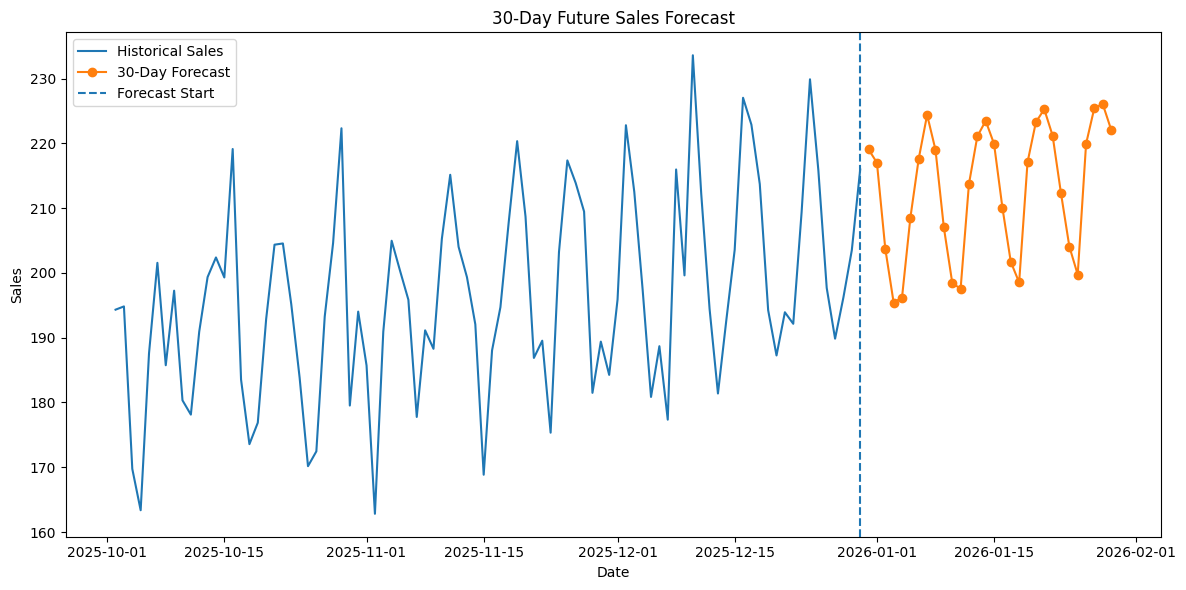

In [20]:
# Show recent historical sales together with the future forecast

recent_history = sales_data.tail(90)

plt.figure(figsize=(12, 6))

plt.plot(
    recent_history["date"],
    recent_history["sales"],
    label="Historical Sales"
)

plt.plot(
    future_forecast["date"],
    future_forecast["forecasted_sales"],
    marker="o",
    label="30-Day Forecast"
)

plt.axvline(
    last_date,
    linestyle="--",
    label="Forecast Start"
)

plt.title("30-Day Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.tight_layout()

plt.show()

## 7. Business Applications

A forecasting workflow like this could support several business decisions.

### Inventory Planning

Expected future sales can help businesses determine how much inventory may be required during upcoming periods.

### Staffing

Forecasted demand patterns could support employee scheduling and resource allocation.

### Purchasing and Supply Planning

Businesses could use forecasts to coordinate supplier orders and reduce the risk of stock shortages or excessive inventory.

### Promotion Planning

Expected high- and low-demand periods could help determine when marketing campaigns or promotions may be most useful.

Forecasts should support business decisions rather than be treated as perfectly accurate predictions. Actual demand can also be influenced by factors that are not represented in historical sales data.

## 8. Limitations

This experiment uses synthetic sales data with intentionally generated trend and seasonal patterns.

Therefore, the forecasting results should be interpreted as a controlled demonstration rather than evidence of performance on real business sales data.

Several limitations should be considered:

- Real sales data may contain missing observations, holidays, promotions, price changes, and unexpected events.
- Seasonal patterns may change over time.
- The models use a limited set of time and lag features.
- Recursive forecasting can accumulate error because earlier predictions are used as inputs for later predictions.
- The experiment produces point forecasts without prediction intervals.
- Model performance should be monitored as new observations become available.

In a real forecasting application, additional variables and specialized time series models could also be evaluated.

## 9. Experiment Conclusion

This experiment replicated and adapted the instructor's time series forecasting project using a reproducible daily sales dataset.

The workflow included:

- Time series exploration
- Trend and weekly pattern analysis
- Lag feature engineering
- Chronological train/test splitting
- Naive baseline forecasting
- Linear Regression
- Random Forest Regression
- Model comparison
- Feature importance analysis
- Recursive future forecasting
- Business interpretation

The models achieved:

- **Naive Baseline:** MAE = 13.07
- **Linear Regression:** MAE = 7.67
- **Random Forest:** MAE = 8.34

Linear Regression achieved the best performance, reducing MAE by approximately 41% compared with the naive baseline.

The Random Forest feature importance analysis identified `lag_7` and `lag_14` as the strongest historical predictors, which is consistent with the weekly seasonal structure of the time series.

The experiment also demonstrates an important forecasting principle: model evaluation must respect chronological order so that future observations do not leak into model training.

Overall, the experiment shows how historical time series patterns can be transformed into predictive features and used to support future business planning.